In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/usaid_clean.parquet")
df = df.dropna(subset=["date_prevue"])

par_an = df.groupby(df["date_prevue"].dt.year)["en_retard"].agg(["count", "mean"])
par_an.columns = ["envois", "pct_retard"]
par_an["pct_retard"] = (par_an["pct_retard"] * 100).round(1)
print(par_an)

             envois  pct_retard
date_prevue                    
2006             65         0.0
2007            672         2.1
2008           1029         1.3
2009           1253         3.6
2010           1204        15.9
2011           1011        23.5
2012           1273         7.9
2013           1272        17.9
2014           1528        15.4
2015           1017        11.8


Corrélation retard / GSCPI : 0.32


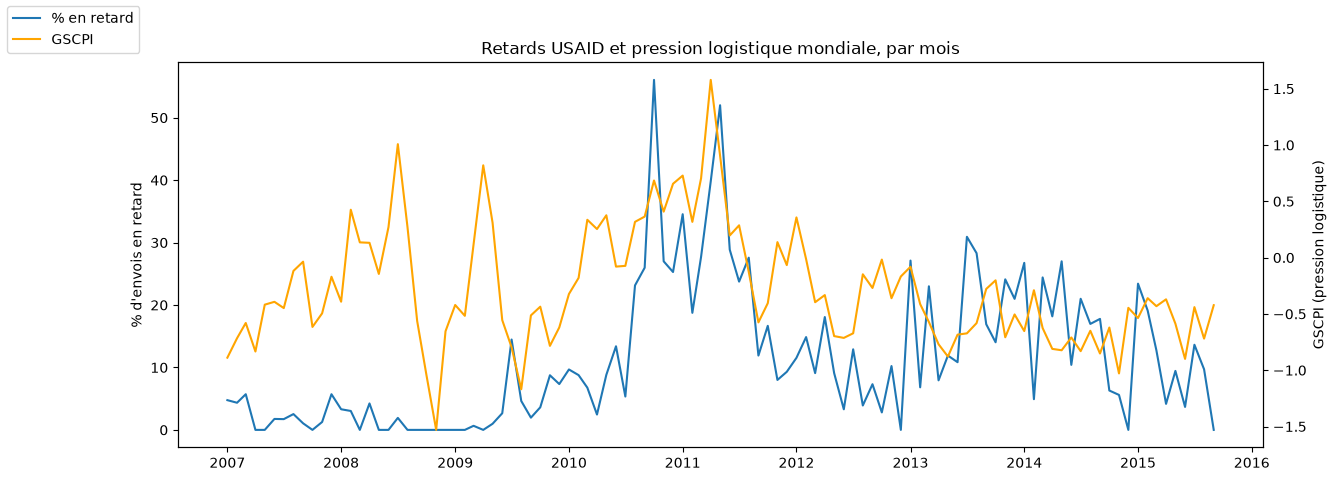

In [3]:
mois = df.groupby(df["date_prevue"].dt.to_period("M"))["en_retard"].agg(["count", "mean"])
mois.index = mois.index.to_timestamp()
mois.columns = ["envois", "pct_retard"]

gscpi = pd.read_csv("../data/raw/external/gscpi.csv", parse_dates=["date"]).set_index("date")["gscpi"]
t = mois.join(gscpi, how="left")
t = t[t["envois"] >= 20]

print("Corrélation retard / GSCPI :", round(t["pct_retard"].corr(t["gscpi"]), 2))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(t.index, t["pct_retard"] * 100, label="% en retard")
ax1.set_ylabel("% d'envois en retard")
ax2 = ax1.twinx()
ax2.plot(t.index, t["gscpi"], color="orange", label="GSCPI")
ax2.set_ylabel("GSCPI (pression logistique)")
ax1.set_title("Retards USAID et pression logistique mondiale, par mois")
fig.legend(loc="upper left")
plt.show()

In [4]:
t2 = t[t.index >= "2010-01-01"]
print("Corrélation retard / GSCPI (depuis 2010) :", round(t2["pct_retard"].corr(t2["gscpi"]), 2))

Corrélation retard / GSCPI (depuis 2010) : 0.45


In [5]:
d = df[df["date_prevue"] >= "2010-01-01"]
print("Envois depuis 2010 :", len(d))

print("\nDate de commande manquante :", round(d["date_commande"].isna().mean() * 100, 1), "%")

print("\nMode de livraison (Fulfill Via) :")
print(d["Fulfill Via"].value_counts())
print("\n% en retard selon le mode de livraison :")
print((d.groupby("Fulfill Via")["en_retard"].mean() * 100).round(1))

print("\nTypes de produits :")
print(d["Product Group"].value_counts())

print("\nNombre de pays de destination :", d["Country"].nunique())
print("Nombre de fournisseurs :", d["Vendor"].nunique())

Envois depuis 2010 : 7305

Date de commande manquante : 50.2 %

Mode de livraison (Fulfill Via) :
Fulfill Via
Direct Drop    3697
From RDC       3608
Name: count, dtype: int64

% en retard selon le mode de livraison :
Fulfill Via
Direct Drop     6.2
From RDC       24.5
Name: en_retard, dtype: float64

Types de produits :
Product Group
ARV     6143
HRDT    1137
ANTM      16
ACT        6
MRDT       3
Name: count, dtype: int64

Nombre de pays de destination : 40
Nombre de fournisseurs : 55


In [9]:
import sys
sys.path.append("..")
import pandas as pd
from sklearn.metrics import roc_auc_score
from src.retard import charger, modele_lgbm, FEATURES_R1

df = charger()
train = df[df["annee"] < 2014]
test = df[df["annee"] == 2014].copy()

risque, modele = modele_lgbm(train, test, FEATURES_R1)
test["risque"] = risque

# 1. Ce que le modèle utilise vraiment (importance par le gain)
imp = pd.Series(modele.booster_.feature_importance(importance_type="gain"),
                index=FEATURES_R1).sort_values(ascending=False)
print("IMPORTANCE (gain) :")
print((imp / imp.sum() * 100).round(1))

# 2. Où il se trompe : AUC séparée pour usine et entrepôt
print("\nAUC PAR MODE DE LIVRAISON :")
for mode, groupe in test.groupby("Fulfill Via", observed=True):
    print(f"{mode} : {len(groupe)} envois, {groupe['en_retard'].mean()*100:.1f} % en retard, "
          f"AUC = {roc_auc_score(groupe['en_retard'], groupe['risque']):.3f}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/usaid_clean.parquet'

In [6]:
print(d["PO Sent to Vendor Date"].value_counts().head(10))

PO Sent to Vendor Date
N/A - From RDC       3608
8/27/14                80
3/19/10                78
8/29/14                76
10/9/14                71
12/2/13                67
Date Not Captured      57
9/24/10                53
2/20/15                43
5/11/15                40
Name: count, dtype: int64
